# Load packages

In [46]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.pyplot as plt
import harmonypy

# Load data

In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import glob
import gzip

files = sorted(glob.glob("Desktop/SCGW_F25/Thesis_GBM/GSE84465_RAW/*.csv.gz"))
print("총 파일 수:", len(files))

genes = None
counts = []

for file in files:
    with gzip.open(file, "rt", errors="ignore") as z:
        lines = z.read().strip().split("\n")

        data_lines = lines[1:]

        gene_list = []
        count_list = []

        for line in data_lines:
            parts = line.strip().split()

            if len(parts) == 2:
                gene, count = parts
            else:
                # count가 없는 경우 → 0으로 처리
                gene = parts[0]
                count = 0

            gene_list.append(gene)
            count_list.append(float(count))

        # 첫 파일의 gene list 저장
        if genes is None:
            genes = gene_list
        else:
            # gene order이 동일한지 체크
            assert genes == gene_list, f"Gene mismatch in {file}"

        counts.append(count_list)

# numpy array 변환
mat = np.array(counts).T  # shape should be (genes, cells)

# AnnData
adata = sc.AnnData(mat.T)
adata.var_names = genes
adata.obs_names = [f.split("/")[-1].replace(".csv.gz", "") for f in files]

print(adata)


총 파일 수: 3589
AnnData object with n_obs × n_vars = 3589 × 23465


In [49]:
adata

AnnData object with n_obs × n_vars = 3589 × 23465

In [50]:
adata.to_df()

,"""1/2-SBSRNA4""","""A1BG""","""A1BG-AS1""","""A1CF""","""A2LD1""","""A2M""","""A2ML1""","""A2MP1""","""A4GALT""","""A4GNT""",...,"""ZYG11B""","""ZYX""","""ZZEF1""","""ZZZ3""","""tAKR""","""no_feature""","""ambiguous""","""too_low_aQual""","""not_aligned""","""alignment_not_unique"""
GSM2243439_1001000173.G8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,429554.0,8372.0,0.0,0.0,111288.0
GSM2243440_1001000173.D4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,73969.0,2297.0,0.0,0.0,19969.0
GSM2243441_1001000173.B4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,834.0,0.0,0.0,0.0,185910.0,12481.0,0.0,0.0,132812.0
GSM2243442_1001000173.A2,0.0,0.0,1.0,0.0,0.0,0.0,34.0,0.0,0.0,0.0,...,0.0,0.0,33.0,1.0,0.0,355266.0,11386.0,0.0,0.0,131212.0
GSM2243443_1001000173.E2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,536444.0,8969.0,0.0,0.0,145595.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM2247073_1001000271.F1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,223514.0,3400.0,0.0,0.0,108873.0
GSM2247074_1001000271.D4,0.0,61.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,173101.0,3605.0,0.0,0.0,64761.0
GSM2247075_1001000271.C1,0.0,0.0,0.0,0.0,0.0,61.0,0.0,0.0,2.0,0.0,...,0.0,18.0,0.0,64.0,0.0,349266.0,8243.0,0.0,0.0,114882.0
GSM2247076_1001000271.H7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3117.0,34.0,0.0,0.0,507.0


In [51]:
import pandas as pd

meta = pd.read_csv("Desktop/SCGW_F25/Thesis_GBM/SraRunTable.csv")
meta.head()

,Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,cell_type,Center Name,Consent,...,ReleaseDate,Sample Name,Selection,source_name,SRA Study,tissue,tsne_cluster,well,create_date,version
0,SRR3934349,RNA-Seq,128,223967101,PRJNA330719,SAMN05421106,85578803,Neoplastic,GEO,public,...,2017-11-02T00:00:00Z,GSM2243439,Unpanned,Brain,SRP079058,Tumor,11,G8,2016-07-20T23:14:00Z,1.0
1,SRR3934350,RNA-Seq,128,158226652,PRJNA330719,SAMN05421107,60181027,Oligodendrocyte,GEO,public,...,2017-11-02T00:00:00Z,GSM2243440,Unpanned,Brain,SRP079058,Tumor,2,D4,2016-07-20T23:13:00Z,1.0
2,SRR3934351,RNA-Seq,128,190712697,PRJNA330719,SAMN05421108,72386867,Neoplastic,GEO,public,...,2017-11-02T00:00:00Z,GSM2243441,Unpanned,Brain,SRP079058,Tumor,11,B4,2016-07-20T23:10:00Z,1.0
3,SRR3934352,RNA-Seq,128,249900053,PRJNA330719,SAMN05421109,95698536,Neoplastic,GEO,public,...,2017-11-02T00:00:00Z,GSM2243442,Unpanned,Brain,SRP079058,Tumor,11,A2,2016-07-20T23:10:00Z,1.0
4,SRR3934353,RNA-Seq,128,253252958,PRJNA330719,SAMN05421110,96374384,Neoplastic,GEO,public,...,2017-11-02T00:00:00Z,GSM2243443,Unpanned,Brain,SRP079058,Tumor,11,E2,2016-07-20T23:14:00Z,1.0


In [52]:
meta["GSM"] = meta["Sample Name"]

In [53]:
gsm_to_tissue = dict(zip(meta["GSM"], meta["tissue"]))

In [54]:
adata.obs["GSM"] = adata.obs_names.str.split("_").str[0]

In [55]:
adata.obs["region"] = adata.obs["GSM"].map(gsm_to_tissue)

In [56]:
adata.obs["region"]

GSM2243439_1001000173.G8    Tumor
GSM2243440_1001000173.D4    Tumor
GSM2243441_1001000173.B4    Tumor
GSM2243442_1001000173.A2    Tumor
GSM2243443_1001000173.E2    Tumor
                            ...  
GSM2247073_1001000271.F1    Tumor
GSM2247074_1001000271.D4    Tumor
GSM2247075_1001000271.C1    Tumor
GSM2247076_1001000271.H7    Tumor
GSM2247077_1001000271.H2    Tumor
Name: region, Length: 3589, dtype: object

In [57]:
gsm_to_patient = dict(zip(meta["GSM"], meta["Patient_ID"]))

In [58]:
adata.obs["Patient_ID"] = adata.obs["GSM"].map(gsm_to_patient)

In [59]:
adata.obs["Patient_ID"].unique()

array(['BT_S2', 'BT_S1', 'BT_S4', 'BT_S6'], dtype=object)

In [60]:
adata.obs

,GSM,region,Patient_ID
GSM2243439_1001000173.G8,GSM2243439,Tumor,BT_S2
GSM2243440_1001000173.D4,GSM2243440,Tumor,BT_S2
GSM2243441_1001000173.B4,GSM2243441,Tumor,BT_S2
GSM2243442_1001000173.A2,GSM2243442,Tumor,BT_S2
GSM2243443_1001000173.E2,GSM2243443,Tumor,BT_S2
...,...,...,...
GSM2247073_1001000271.F1,GSM2247073,Tumor,BT_S6
GSM2247074_1001000271.D4,GSM2247074,Tumor,BT_S6
GSM2247075_1001000271.C1,GSM2247075,Tumor,BT_S6
GSM2247076_1001000271.H7,GSM2247076,Tumor,BT_S6


In [61]:
adata

AnnData object with n_obs × n_vars = 3589 × 23465
    obs: 'GSM', 'region', 'Patient_ID'

# Dimensionality Reduction and Cell Clustering

### Standard QC metrics

In [62]:
adata.obs["batch_id"] = adata.obs["Patient_ID"].astype("category")

In [63]:
adata.obs["batch_id"].value_counts()

batch_id
BT_S4    1542
BT_S2    1169
BT_S1     489
BT_S6     389
Name: count, dtype: int64

In [64]:
sc.pp.calculate_qc_metrics(adata, inplace=True)

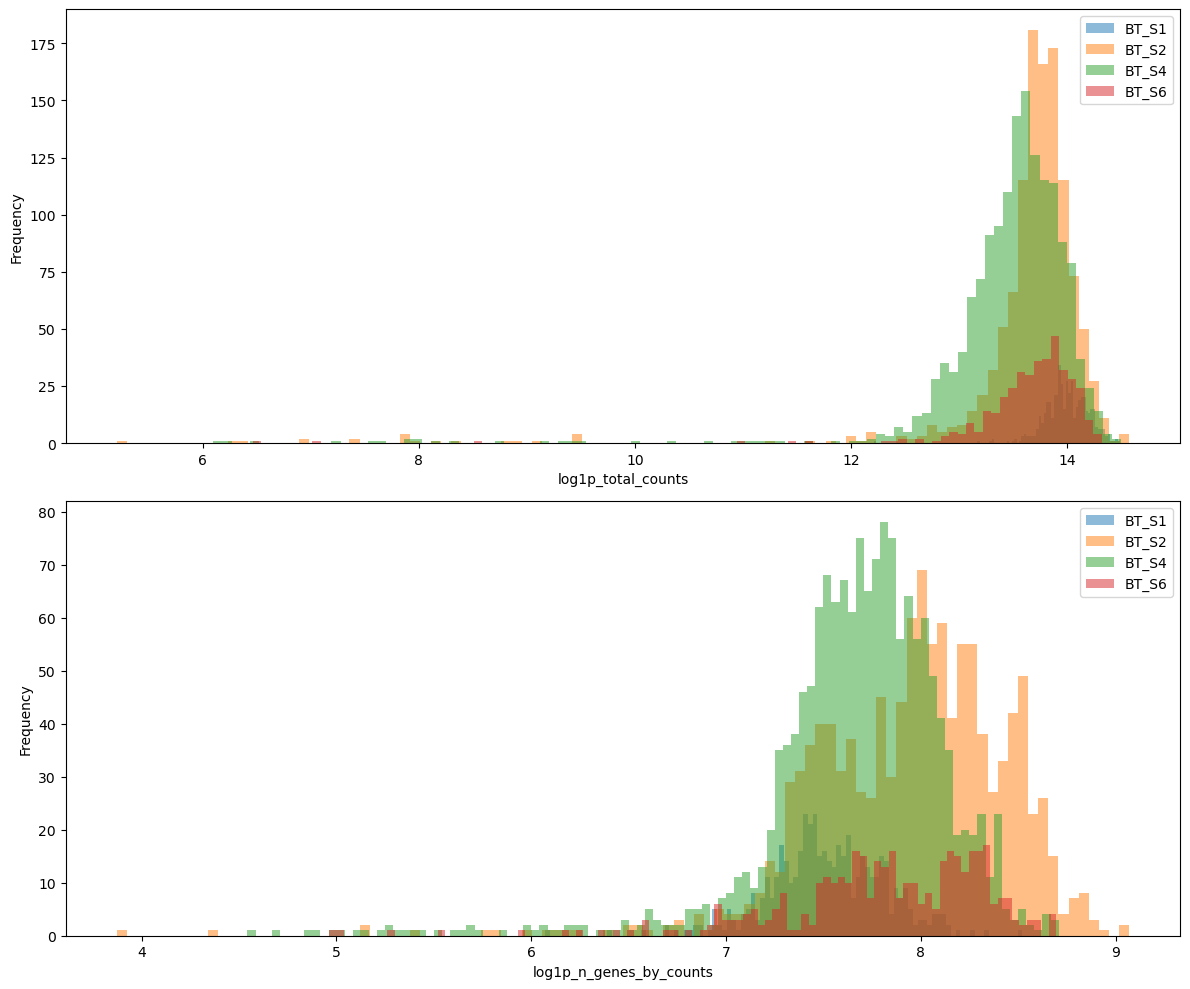

In [65]:
import matplotlib.pyplot as plt

batches = adata.obs["batch_id"].cat.categories

fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# -------------------------------
# 1) Library size (total counts)
# -------------------------------

for b in batches:
    subset = adata[adata.obs["batch_id"] == b]
    axs[0].hist(subset.obs["log1p_total_counts"], bins=100, alpha=0.5, label=b)

axs[0].set_xlabel("log1p_total_counts")
axs[0].set_ylabel("Frequency")
axs[0].legend()

# -------------------------------
# 2) Number of genes per cell
# -------------------------------

for b in batches:
    subset = adata[adata.obs["batch_id"] == b]
    axs[1].hist(subset.obs["log1p_n_genes_by_counts"], bins=100, alpha=0.5, label=b)

axs[1].set_xlabel("log1p_n_genes_by_counts")
axs[1].set_ylabel("Frequency")
axs[1].legend()

plt.tight_layout()
plt.show()


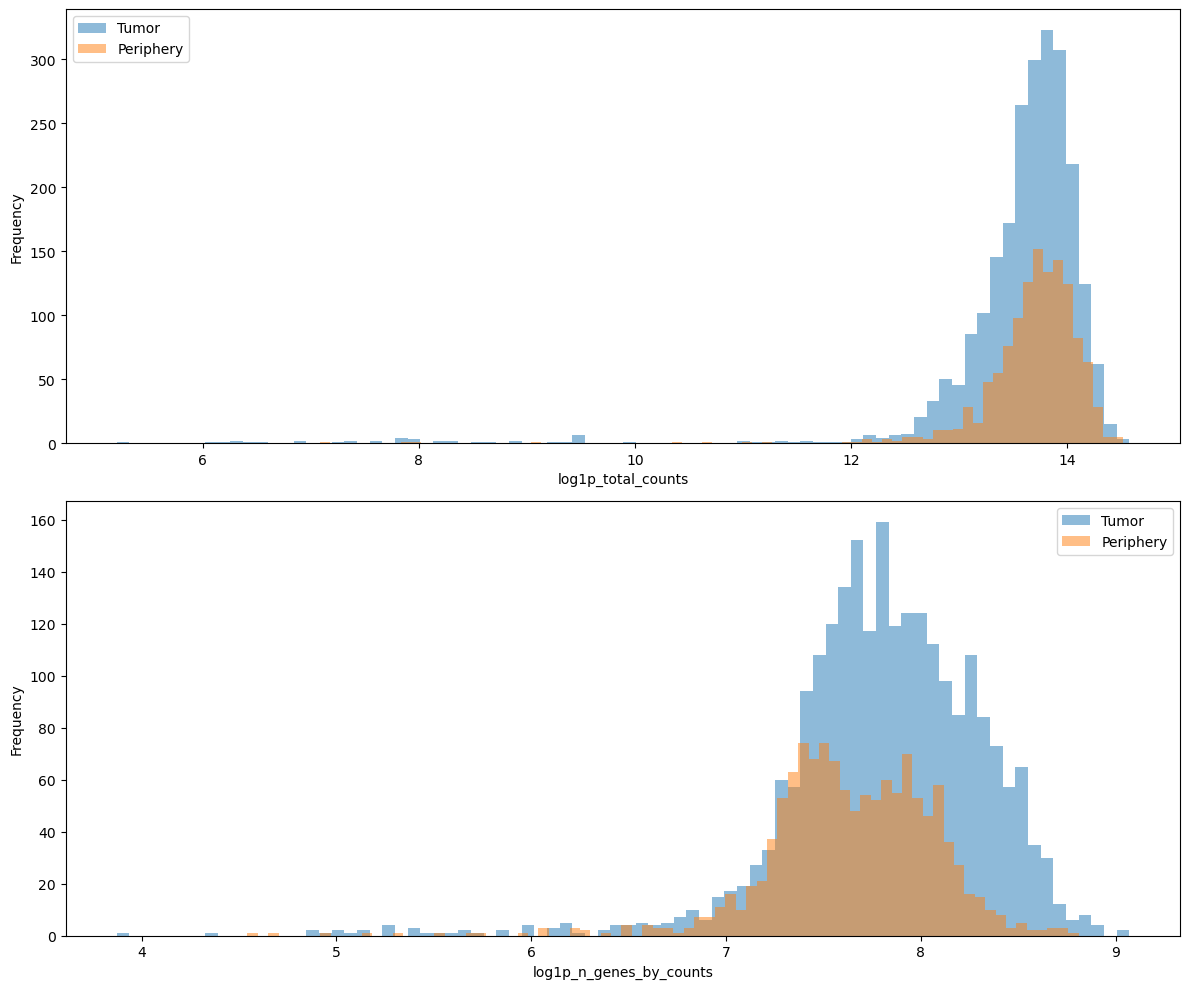

In [66]:
import matplotlib.pyplot as plt

groups = adata.obs["region"].unique()

fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# 1) total counts
for g in groups:
    subset = adata[adata.obs["region"] == g]
    axs[0].hist(subset.obs["log1p_total_counts"], bins=80, alpha=0.5, label=g)

axs[0].set_xlabel("log1p_total_counts")
axs[0].set_ylabel("Frequency")
axs[0].legend()

# 2) number of genes
for g in groups:
    subset = adata[adata.obs["region"] == g]
    axs[1].hist(subset.obs["log1p_n_genes_by_counts"], bins=80, alpha=0.5, label=g)

axs[1].set_xlabel("log1p_n_genes_by_counts")
axs[1].set_ylabel("Frequency")
axs[1].legend()

plt.tight_layout()
plt.show()


/Users/jungjiwon/miniconda3/envs/scgw_f25/lib/python3.12/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


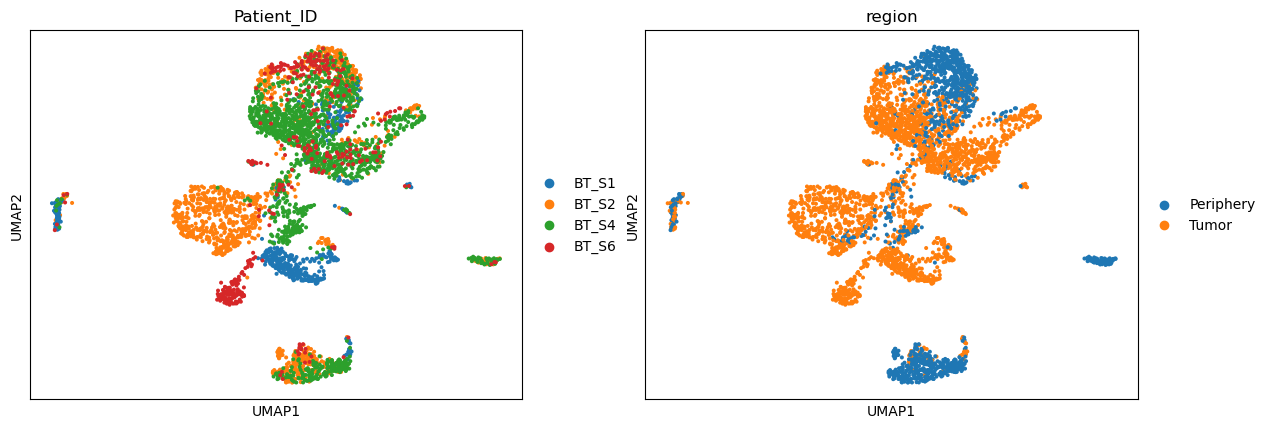

In [67]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)
adata = adata[:, adata.var['highly_variable']]
sc.pp.scale(adata)
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

sc.pl.umap(adata, color=["Patient_ID", "region"])

(0.0, 500.0)

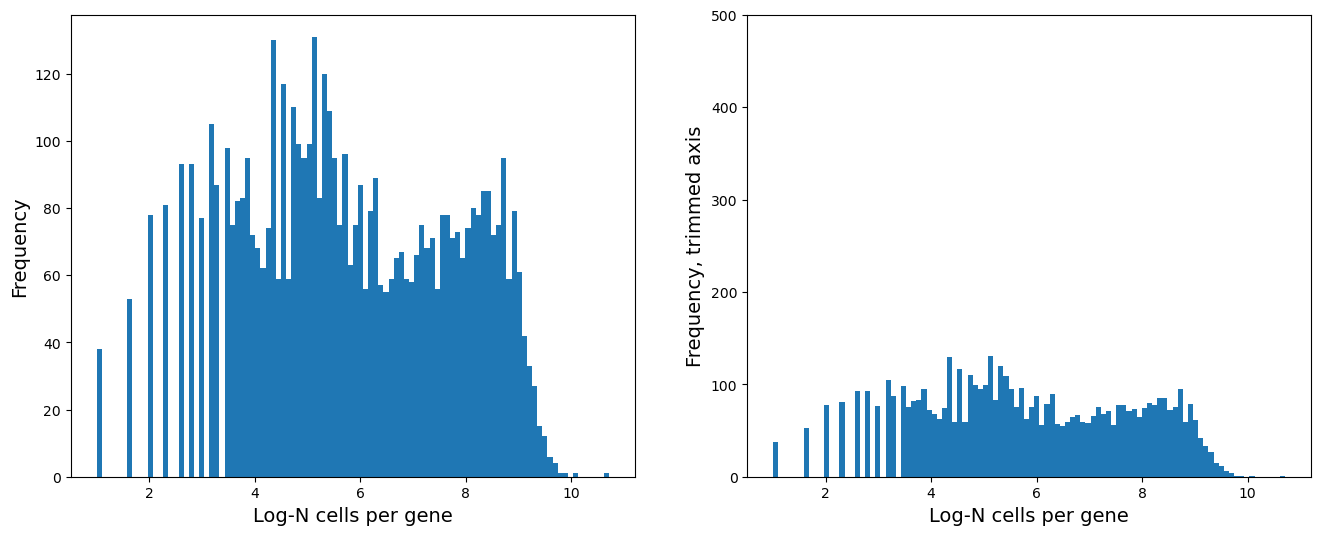

In [68]:
# Distribution of number of genes a cell is expressed in
fig = plt.figure(figsize = (8*2, 6*1))
ax = fig.add_subplot(1, 2, 1)
ax.hist(np.log2(adata.var['n_cells_by_counts'] + 1), 100)
ax.set_xlabel('Log-N cells per gene', fontsize = 14)
ax.set_ylabel('Frequency', fontsize = 14)

ax = fig.add_subplot(1, 2, 2)
ax.hist(np.log2(adata.var['n_cells_by_counts'] + 1), 100)
ax.set_xlabel('Log-N cells per gene', fontsize = 14)
ax.set_ylabel('Frequency, trimmed axis', fontsize = 14)
ax.set_ylim([0, 500])

In [69]:
# (1) 유전자가 200개 미만인 세포 제거
sc.pp.filter_cells(adata, min_genes=200)

# (2) 유전자가 10000개 초과인 세포 제거
sc.pp.filter_cells(adata, max_genes=10000)

In [70]:
adata

AnnData object with n_obs × n_vars = 1280 × 5447
    obs: 'GSM', 'region', 'Patient_ID', 'batch_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'Patient_ID_colors', 'region_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [71]:
# 3개 미만의 세포에서만 발현된 gene 제거 (최소 3개의 단일 세포에서 발현되는 gene만)
sc.pp.filter_genes(adata, min_cells=3)

In [72]:
adata

AnnData object with n_obs × n_vars = 1280 × 5114
    obs: 'GSM', 'region', 'Patient_ID', 'batch_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'n_cells'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'Patient_ID_colors', 'region_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

### % mito

In [73]:
adata.var['mt'] = adata.var_names.str.contains('mt', case=False)

In [74]:
# check to make sure only MT- genes are considered
adata.var_names[adata.var['mt']] 

Index(['"ADAMTS10"', '"ADAMTS12"', '"ADAMTS15"', '"ADAMTS16"', '"ADAMTS19"',
       '"ADAMTS2"', '"ADAMTS4"', '"ADAMTS6"', '"ADAMTS8"', '"ADAMTS9"',
       '"ADAMTSL1"', '"ADAMTSL2"', '"ADAMTSL3"', '"ADAMTSL5"', '"BHMT2"',
       '"CKMT1A"', '"CMTM2"', '"DNMT3B"', '"FERMT1"', '"INMT"',
       '"INMT-FAM188B"', '"LCMT2"', '"MGMT"', '"MT1A"', '"MT1G"', '"MT1H"',
       '"MTERF"', '"MTIF2"', '"MTMR7"', '"MTMR8"', '"MTNR1A"', '"MTO1"',
       '"MTRNR2L3"', '"MTRNR2L4"', '"MTVR2"', '"MTX3"', '"N6AMT1"', '"NMT2"',
       '"PNMT"', '"POLRMT"', '"POMT2"', '"PRMT10"', '"PRMT7"', '"PRMT8"',
       '"SMTN"', '"SMTNL1"', '"TMTC1"', '"TMTC2"', '"TMTC4"', '"TRMT12"',
       '"TRMT1L"', '"TRMT2A"'],
      dtype='object')

In [75]:
# compute the % of mito content for each cell
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [76]:
adata

AnnData object with n_obs × n_vars = 1280 × 5114
    obs: 'GSM', 'region', 'Patient_ID', 'batch_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'total_counts_mt', 'pct_counts_mt'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'n_cells', 'mt'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'Patient_ID_colors', 'region_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [77]:
patients = adata.obs['Patient_ID'].unique().tolist()
colors = plt.cm.tab10(np.linspace(0, 1, len(patients)))

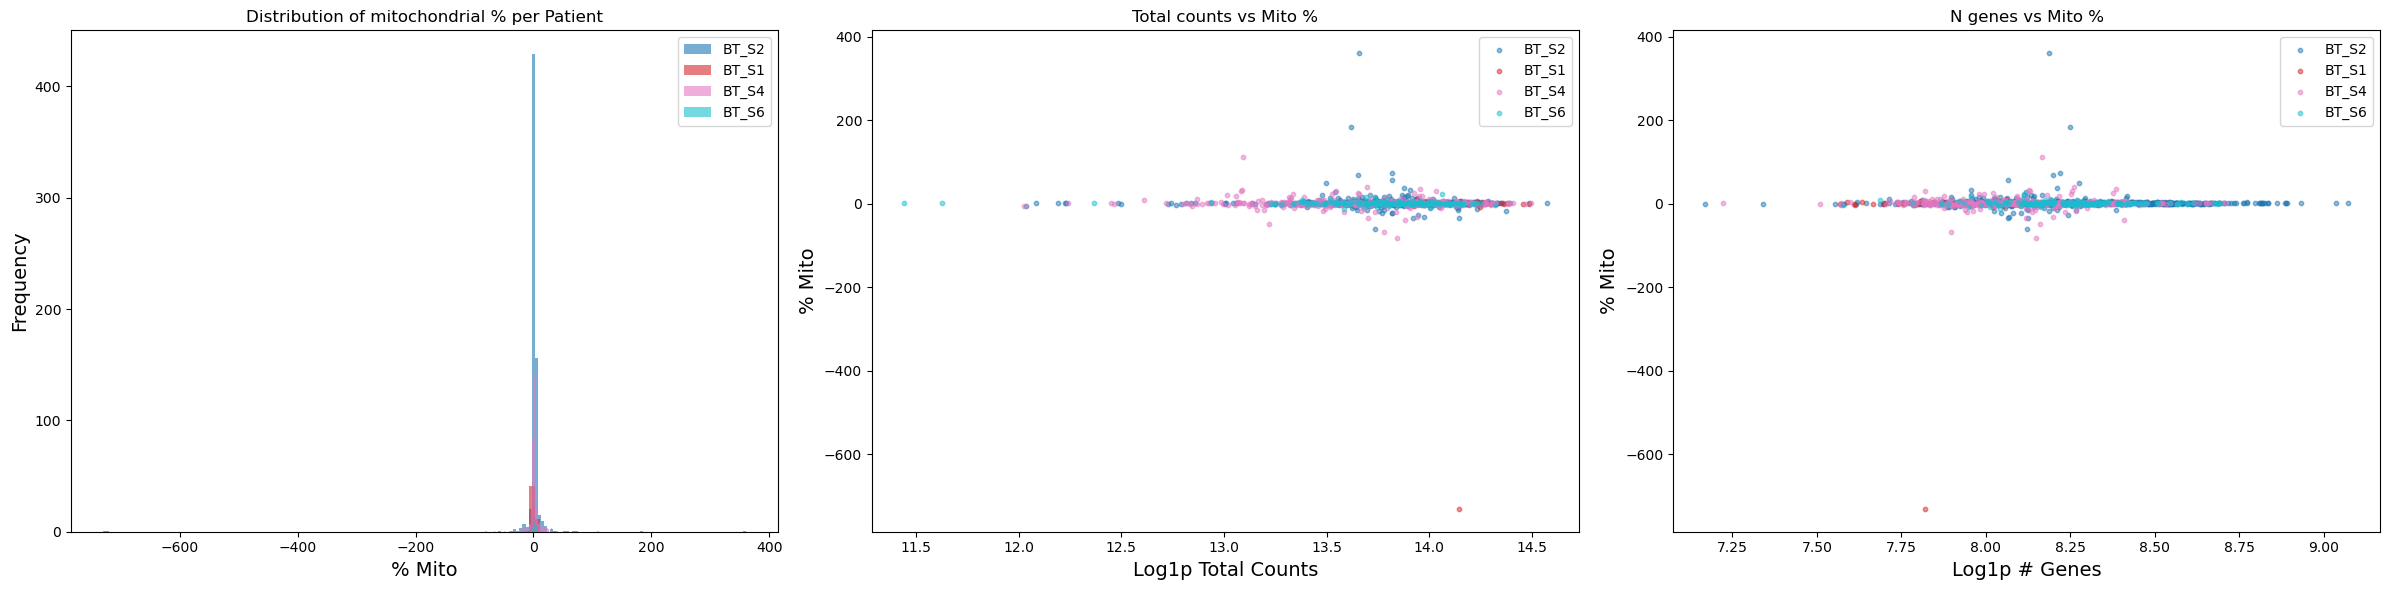

In [78]:
fig = plt.figure(figsize=(24, 6))

# 1) Histogram of % mito per patient
ax = fig.add_subplot(1, 3, 1)
for i, pt in enumerate(patients):
    subset = adata.obs['pct_counts_mt'][adata.obs['Patient_ID'] == pt]
    ax.hist(subset, bins=80, alpha=0.6, label=pt, color=colors[i])
ax.set_xlabel('% Mito', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.legend(fontsize=10)
ax.set_title('Distribution of mitochondrial % per Patient')

# 2) Log total counts vs % mito
ax = fig.add_subplot(1, 3, 2)
for i, pt in enumerate(patients):
    subset = adata.obs[adata.obs['Patient_ID'] == pt]
    ax.scatter(subset['log1p_total_counts'], subset['pct_counts_mt'],
               alpha=0.5, label=pt, color=colors[i], s=10)
ax.set_xlabel('Log1p Total Counts', fontsize=14)
ax.set_ylabel('% Mito', fontsize=14)
ax.legend(fontsize=10)
ax.set_title('Total counts vs Mito %')

# 3) Log n_genes vs % mito
ax = fig.add_subplot(1, 3, 3)
for i, pt in enumerate(patients):
    subset = adata.obs[adata.obs['Patient_ID'] == pt]
    ax.scatter(subset['log1p_n_genes_by_counts'], subset['pct_counts_mt'],
               alpha=0.5, label=pt, color=colors[i], s=10)
ax.set_xlabel('Log1p # Genes', fontsize=14)
ax.set_ylabel('% Mito', fontsize=14)
ax.legend(fontsize=10)
ax.set_title('N genes vs Mito %')

plt.tight_layout()
plt.show()


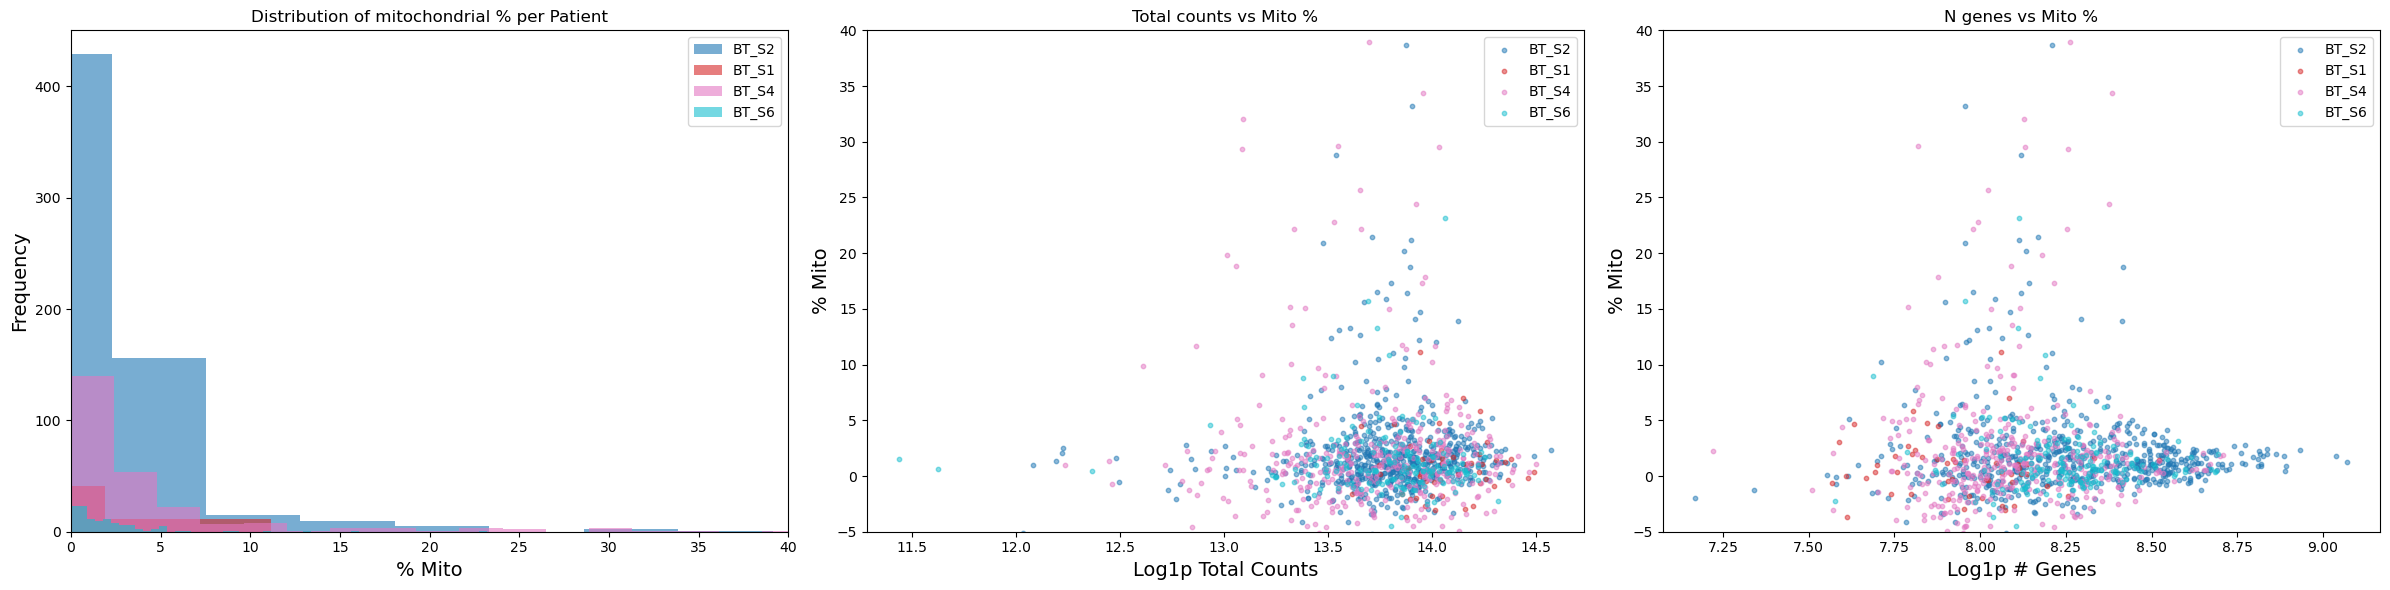

In [79]:
fig = plt.figure(figsize=(24, 6))

# ===== (1) Histogram =====
ax = fig.add_subplot(1, 3, 1)
for i, pt in enumerate(patients):
    subset = adata.obs['pct_counts_mt'][adata.obs['Patient_ID'] == pt]
    ax.hist(subset, bins=80, alpha=0.6, label=pt, color=colors[i])
ax.set_xlabel('% Mito', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.set_title('Distribution of mitochondrial % per Patient')
ax.set_xlim(0, 40)     # ★ mitochondrial %는 보통 0~40% 사이
ax.legend(fontsize=10)

# ===== (2) Log total counts vs % mito =====
ax = fig.add_subplot(1, 3, 2)
for i, pt in enumerate(patients):
    subset = adata.obs[adata.obs['Patient_ID'] == pt]
    ax.scatter(subset['log1p_total_counts'], subset['pct_counts_mt'],
               alpha=0.5, label=pt, color=colors[i], s=10)
ax.set_xlabel('Log1p Total Counts', fontsize=14)
ax.set_ylabel('% Mito', fontsize=14)
ax.set_title('Total counts vs Mito %')
ax.set_ylim(-5, 40)    # ★ y-axis 조절
ax.legend(fontsize=10)

# ===== (3) Log n_genes vs % mito =====
ax = fig.add_subplot(1, 3, 3)
for i, pt in enumerate(patients):
    subset = adata.obs[adata.obs['Patient_ID'] == pt]
    ax.scatter(subset['log1p_n_genes_by_counts'], subset['pct_counts_mt'],
               alpha=0.5, label=pt, color=colors[i], s=10)
ax.set_xlabel('Log1p # Genes', fontsize=14)
ax.set_ylabel('% Mito', fontsize=14)
ax.set_title('N genes vs Mito %')
ax.set_ylim(-5, 40)    # ★ y-axis 조절
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


In [80]:
# Remove cells with more than 20% mitochondrial content
adata = adata[adata.obs['pct_counts_mt'] < 20, :]

In [81]:
adata

View of AnnData object with n_obs × n_vars = 1254 × 5114
    obs: 'GSM', 'region', 'Patient_ID', 'batch_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'total_counts_mt', 'pct_counts_mt'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'n_cells', 'mt'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'Patient_ID_colors', 'region_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

### Remove ribosomal genes

In [82]:
# Identify ribosomal genes - as those that start with RPS or RPL in the human genome
adata.var['ribo'] = adata.var_names.str.startswith(('RPS', 'RPL'))

/var/folders/qb/j91szx0j14n_d2hyg3c53v2m0000gn/T/ipykernel_38302/2985208644.py:2: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['ribo'] = adata.var_names.str.startswith(('RPS', 'RPL'))


In [83]:
adata = adata[:, ~adata.var_names.str.startswith(('RPS', 'RPL'))]

In [84]:
adata

View of AnnData object with n_obs × n_vars = 1254 × 5114
    obs: 'GSM', 'region', 'Patient_ID', 'batch_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'total_counts_mt', 'pct_counts_mt'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'n_cells', 'mt', 'ribo'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'Patient_ID_colors', 'region_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

# Highly Variable Genes (HVGs) 선택

In [85]:
adata.var_names = adata.var_names.str.replace('"', '')
adata.var_names_make_unique()

In [86]:
# HVG
sc.pp.highly_variable_genes(adata, n_top_genes = 2000, flavor = 'seurat')

In [87]:
adata

AnnData object with n_obs × n_vars = 1254 × 5114
    obs: 'GSM', 'region', 'Patient_ID', 'batch_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'total_counts_mt', 'pct_counts_mt'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'n_cells', 'mt', 'ribo'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'Patient_ID_colors', 'region_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [88]:
print("Any NaN in X?", np.isnan(adata.X).sum())
print("Mean of genes (first 20):", np.array(adata.X.mean(axis=0)).flatten()[:20])
print("Unique mean values:", np.unique(np.array(adata.X.mean(axis=0)).flatten()[:50]))
print("Min/Max of X:", adata.X.min(), adata.X.max())

Any NaN in X? 0
Mean of genes (first 20): [ 0.05450637  0.01197366 -0.03878834  0.07411365  0.17610103  0.19157911
  0.07443252  0.10657888  0.23256269  0.10285894 -0.03353008  0.14307828
  0.12649661  0.09490929  0.01823731  0.02489034  0.01155694  0.03679267
  0.0219268   0.26593956]
Unique mean values: [-0.08494419 -0.07960452 -0.07411408 -0.05362445 -0.05271618 -0.03878834
 -0.03353008 -0.02331731 -0.01706716 -0.00425336 -0.00400909  0.01155694
  0.01197366  0.01698402  0.01823731  0.0219268   0.02489034  0.03394575
  0.03679267  0.0472023   0.05450637  0.05630533  0.05871452  0.05947092
  0.05992946  0.06493867  0.07411365  0.07443252  0.07976233  0.08524736
  0.09205841  0.09490929  0.09710786  0.10285894  0.10657888  0.11588441
  0.12649661  0.14307828  0.17610103  0.17705059  0.19003461  0.19157911
  0.19396129  0.23256269  0.25580247  0.26593956  0.28297879  0.31782446
  0.33842526  0.45327645]
Min/Max of X: -0.7831682062716939 59.45700428872653


In [89]:
adata = adata[:, adata.var['highly_variable']]

# Scale the data

In [90]:
sc.pp.scale(adata, max_value=10)

/Users/jungjiwon/miniconda3/envs/scgw_f25/lib/python3.12/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


# PCA

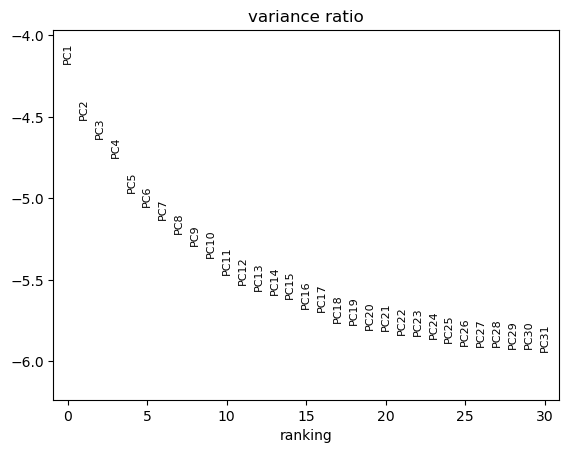

In [91]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True)

# Batch correction (Patient_ID 기반)

In [93]:
import harmonypy as hm

ho = hm.run_harmony(adata.obsm['X_pca'],
                    adata.obs,
                    'Patient_ID')

adata.obsm['X_pca_harmony'] = ho.Z_corr.T


2025-12-11 02:32:49,322 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-12-11 02:32:49,577 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-12-11 02:32:49,583 - harmonypy - INFO - Iteration 1 of 10
2025-12-11 02:32:49,711 - harmonypy - INFO - Iteration 2 of 10
2025-12-11 02:32:49,860 - harmonypy - INFO - Converged after 2 iterations


In [94]:
adata.obsm['X_pca'] = adata.obsm['X_pca_harmony']

# Neighbor graph + UMAP + clustering

In [95]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)

/var/folders/qb/j91szx0j14n_d2hyg3c53v2m0000gn/T/ipykernel_38302/453030637.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


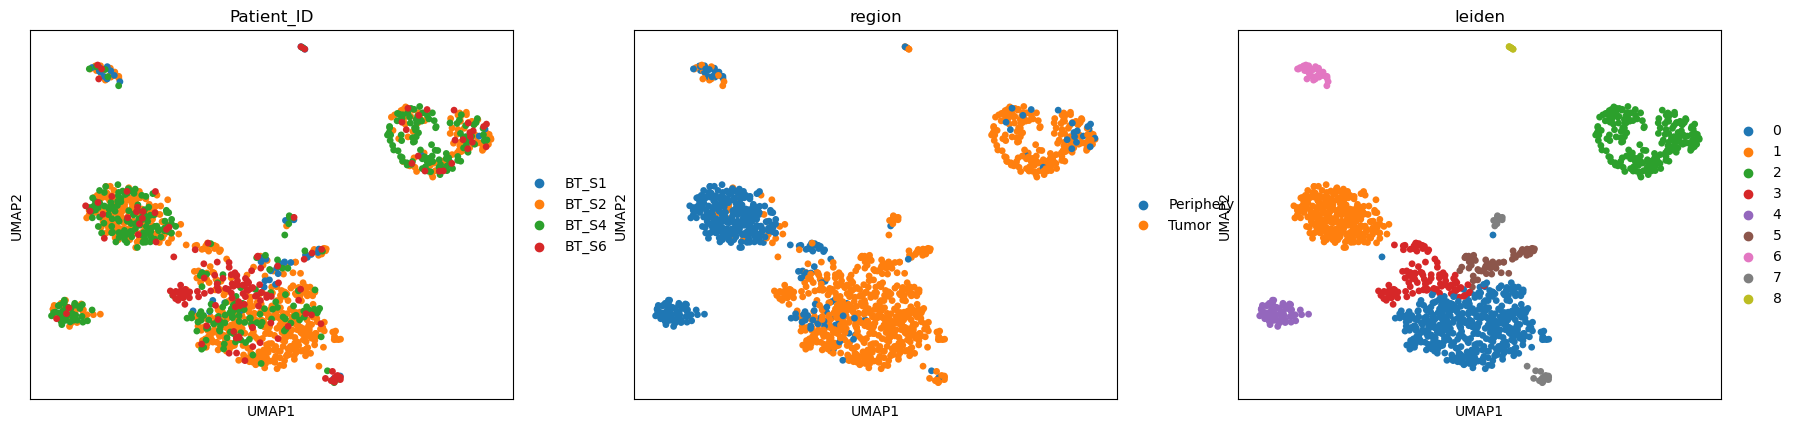

In [96]:
sc.pl.umap(adata, color=['Patient_ID', 'region', 'leiden'])

# 각 클러스터 마커 탐색 (FindAllMarkers equivalent)

/Users/jungjiwon/miniconda3/envs/scgw_f25/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/jungjiwon/miniconda3/envs/scgw_f25/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/jungjiwon/miniconda3/envs/scgw_f25/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/jungjiwon/miniconda3/envs/scgw_f25/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/jungjiwon/miniconda3/envs/scgw_f25/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value

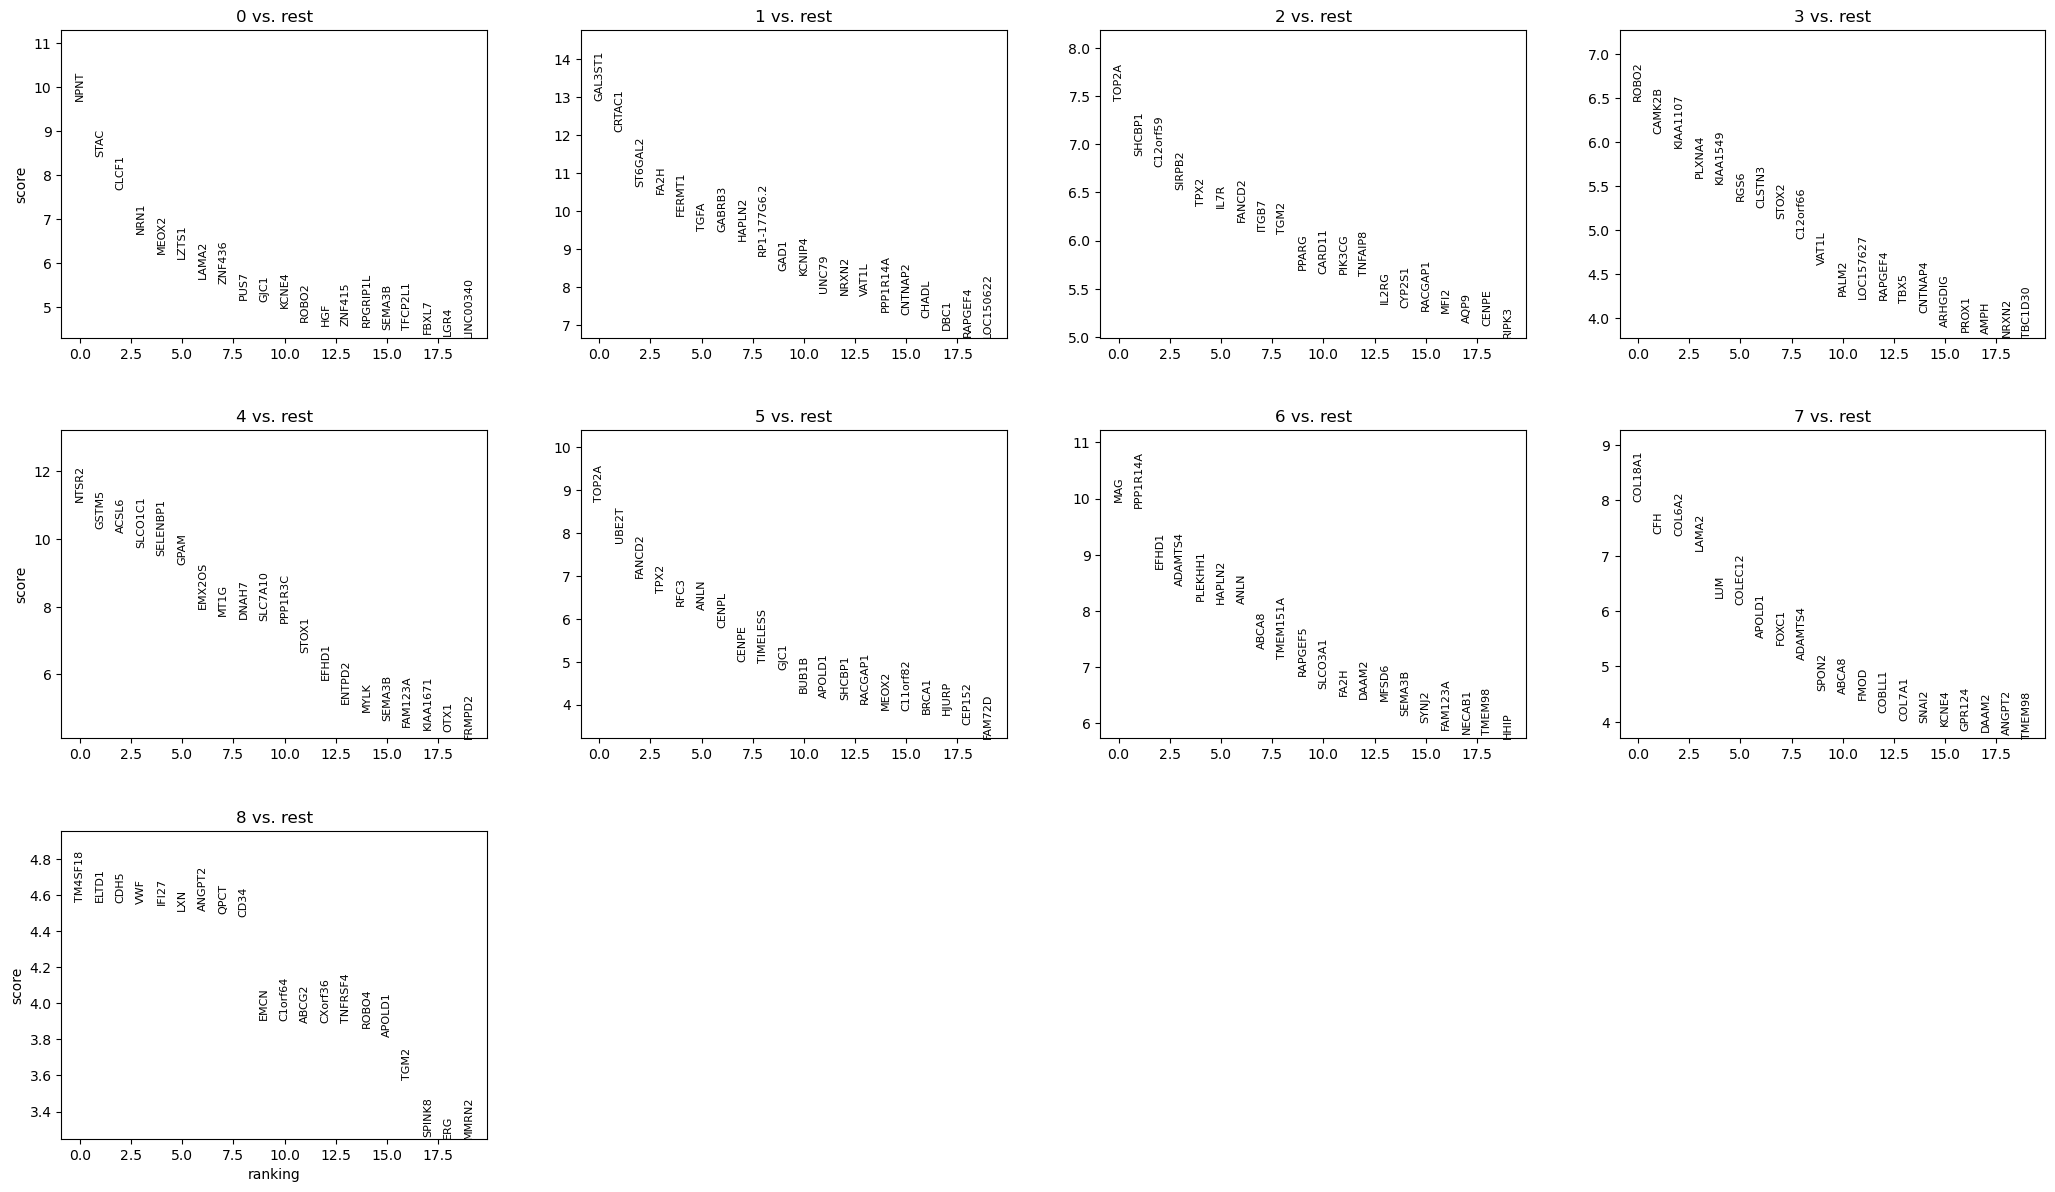

In [97]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

In [98]:
adata.obs['leiden'].value_counts()

leiden
0    460
1    285
2    207
3    111
4     64
5     59
6     34
7     27
8      7
Name: count, dtype: int64

# Cell Type Annotation and Differential Expression

In [100]:
sc.tl.rank_genes_groups(adata, groupby='leiden', method = 'wilcoxon', key_added='cluster_vs_rest')

/Users/jungjiwon/miniconda3/envs/scgw_f25/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/jungjiwon/miniconda3/envs/scgw_f25/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/jungjiwon/miniconda3/envs/scgw_f25/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/jungjiwon/miniconda3/envs/scgw_f25/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/jungjiwon/miniconda3/envs/scgw_f25/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value

In [101]:
adata

AnnData object with n_obs × n_vars = 1254 × 2000
    obs: 'GSM', 'region', 'Patient_ID', 'batch_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'n_cells', 'mt', 'ribo'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'Patient_ID_colors', 'region_colors', 'leiden', 'leiden_colors', 'rank_genes_groups', 'cluster_vs_rest'
    obsm: 'X_pca', 'X_umap', 'X_pca_harmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [102]:
adata.uns['cluster_vs_rest']

{'params': {'groupby': 'leiden',
  'reference': 'rest',
  'method': 'wilcoxon',
  'use_raw': False,
  'layer': None,
  'corr_method': 'benjamini-hochberg'},
 'names': rec.array([('NPNT', 'GAL3ST1', 'TOP2A', 'ROBO2', 'NTSR2', 'TOP2A', 'MAG', 'COL18A1', 'TM4SF18'),
            ('STAC', 'CRTAC1', 'SHCBP1', 'CAMK2B', 'GSTM5', 'UBE2T', 'PPP1R14A', 'CFH', 'ELTD1'),
            ('CLCF1', 'ST6GAL2', 'C12orf59', 'KIAA1107', 'ACSL6', 'FANCD2', 'EFHD1', 'COL6A2', 'CDH5'),
            ...,
            ('GABRB3', 'SLCO1C1', 'ZNF423', 'FA2H', 'GJC1', 'GAL3ST1', 'ZNF544', 'SLC4A3', 'UNC79'),
            ('FA2H', 'GJC1', 'ZNF415', 'GAL3ST1', 'PLXNA4', 'UNC5C', 'NRXN2', 'PLXNA4', 'ARHGAP33'),
            ('GAL3ST1', 'LAMA2', 'NRXN2', 'PPP1R14A', 'NRXN2', 'SEMA3B', 'TSHZ3', 'UNC79', 'NRXN2')],
           dtype=[('0', 'O'), ('1', 'O'), ('2', 'O'), ('3', 'O'), ('4', 'O'), ('5', 'O'), ('6', 'O'), ('7', 'O'), ('8', 'O')]),
 'scores': rec.array([( 9.681974 , 12.9028   ,  7.4470043,  6.466607 , 11.109595 ,  8

In [103]:
sc.get.rank_genes_groups_df(adata, key='cluster_vs_rest', group='0')

,names,scores,logfoldchanges,pvals,pvals_adj
0,NPNT,9.681974,NaN,3.597020e-22,7.194040e-19
1,STAC,8.416452,NaN,3.880568e-17,3.880568e-14
2,CLCF1,7.666022,NaN,1.774127e-14,1.182751e-11
3,NRN1,6.651615,NaN,2.898952e-11,1.449476e-08
4,MEOX2,6.204479,NaN,5.487838e-10,2.195135e-07
...,...,...,...,...,...
1995,ADARB2,-5.518769,NaN,3.413826e-08,5.252041e-06
1996,HAPLN2,-5.533088,NaN,3.146410e-08,5.252041e-06
1997,GABRB3,-5.576127,NaN,2.459321e-08,4.918642e-06
1998,FA2H,-5.640281,NaN,1.697728e-08,4.015787e-06


## Utilizing clustering results and DEGs to investigate QC metrics of data

### Investigate % mito content, library size, number of genes expressed in each cluster

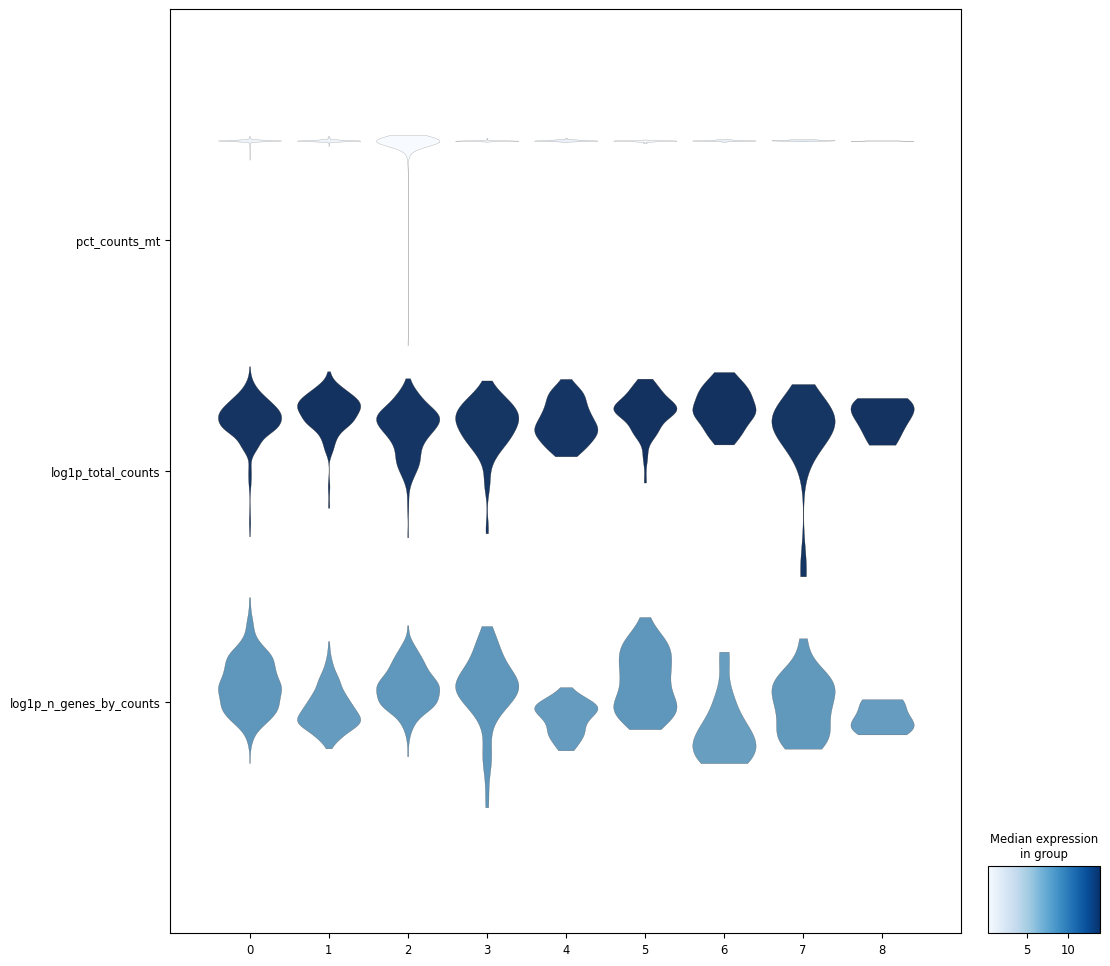

In [104]:
sc.pl.stacked_violin(adata, var_names = ['pct_counts_mt', 'log1p_total_counts', 'log1p_n_genes_by_counts'], groupby='leiden', swap_axes=True, 
                     figsize = (12, 12))

### Alternate visual

In [105]:
df_temp = pd.DataFrame({'leiden': adata.obs['leiden'], 
                        '%-Mito': adata.obs['pct_counts_mt'], 
                        'library_size': adata.obs['log1p_total_counts'], 
                        'n_genes_per_cell': adata.obs['log1p_n_genes_by_counts'],  
                        }, index = adata.obs.index)

In [106]:
df_temp.head()

,leiden,%-Mito,library_size,n_genes_per_cell
GSM2243441_1001000173.B4,0,2.238364,13.911904,8.677780
GSM2243442_1001000173.A2,0,2.957068,14.085603,8.320448
GSM2243445_1001000173.B12,0,0.792551,14.009576,8.705497
GSM2243446_1001000173.D6,1,0.960770,14.026148,8.404696
GSM2243447_1001000173.H1,0,-0.027174,13.849943,8.418036


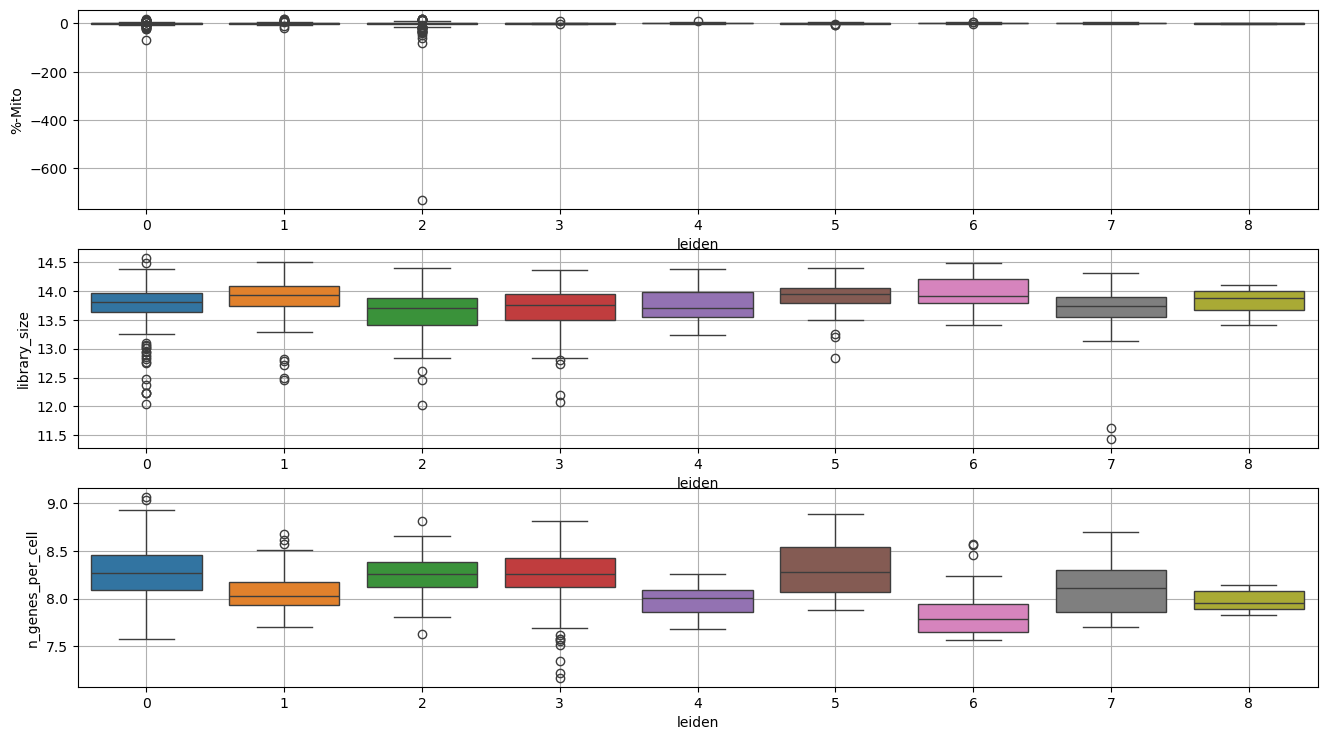

In [107]:
import seaborn as sns
fig = plt.figure(figsize = (8*2, 3*5))
for j, item in enumerate(df_temp.columns[1:]):
    ax = fig.add_subplot(5, 1, j+1)
    sns.boxplot(x = "leiden", y = item, hue = 'leiden', data = df_temp, ax = ax, palette = adata.uns['leiden_colors'])
    ax.grid('on')

In [108]:
#각 클러스터별 상위 유전자 리스트 확인하기
clusters = adata.obs['leiden'].unique()

for clust in clusters:
    df = sc.get.rank_genes_groups_df(adata, key='cluster_vs_rest', group=str(clust)).head(10)
    print(f"Cluster {clust} top genes: {df['names'].tolist()}")

Cluster 0 top genes: ['NPNT', 'STAC', 'CLCF1', 'NRN1', 'MEOX2', 'LZTS1', 'LAMA2', 'ZNF436', 'PUS7', 'GJC1']
Cluster 1 top genes: ['GAL3ST1', 'CRTAC1', 'ST6GAL2', 'FA2H', 'FERMT1', 'TGFA', 'GABRB3', 'HAPLN2', 'RP1-177G6.2', 'GAD1']
Cluster 6 top genes: ['MAG', 'PPP1R14A', 'EFHD1', 'ADAMTS4', 'PLEKHH1', 'HAPLN2', 'ANLN', 'ABCA8', 'TMEM151A', 'RAPGEF5']
Cluster 5 top genes: ['TOP2A', 'UBE2T', 'FANCD2', 'TPX2', 'RFC3', 'ANLN', 'CENPL', 'CENPE', 'TIMELESS', 'GJC1']
Cluster 3 top genes: ['ROBO2', 'CAMK2B', 'KIAA1107', 'PLXNA4', 'KIAA1549', 'RGS6', 'CLSTN3', 'STOX2', 'C12orf66', 'VAT1L']
Cluster 7 top genes: ['COL18A1', 'CFH', 'COL6A2', 'LAMA2', 'LUM', 'COLEC12', 'APOLD1', 'FOXC1', 'ADAMTS4', 'SPON2']
Cluster 2 top genes: ['TOP2A', 'SHCBP1', 'C12orf59', 'SIRPB2', 'TPX2', 'IL7R', 'FANCD2', 'ITGB7', 'TGM2', 'PPARG']
Cluster 4 top genes: ['NTSR2', 'GSTM5', 'ACSL6', 'SLCO1C1', 'SELENBP1', 'GPAM', 'EMX2OS', 'MT1G', 'DNAH7', 'SLC7A10']
Cluster 8 top genes: ['TM4SF18', 'ELTD1', 'CDH5', 'VWF', 'IFI27

## Top 10 differentially expressed marker genes

In [109]:
sc.get.rank_genes_groups_df(adata, key='cluster_vs_rest', group='0').head(10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,NPNT,9.681974,NaN,3.597020e-22,7.194040e-19
1,STAC,8.416452,NaN,3.880568e-17,3.880568e-14
2,CLCF1,7.666022,NaN,1.774127e-14,1.182751e-11
3,NRN1,6.651615,NaN,2.898952e-11,1.449476e-08
4,MEOX2,6.204479,NaN,5.487838e-10,2.195135e-07
5,LZTS1,6.090814,NaN,1.123378e-09,3.744594e-07
6,LAMA2,5.629521,NaN,1.807104e-08,4.015787e-06
7,ZNF436,5.525403,NaN,3.287306e-08,5.252041e-06
8,PUS7,5.153828,NaN,2.552218e-07,3.402958e-05
9,GJC1,5.106259,NaN,3.285995e-07,4.107494e-05


In [110]:
sc.get.rank_genes_groups_df(adata, key='cluster_vs_rest', group='1').head(10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,GAL3ST1,12.902800,NaN,4.340398e-38,8.680796e-35
1,CRTAC1,12.087425,NaN,1.230839e-33,1.230839e-30
2,ST6GAL2,10.656520,NaN,1.625665e-26,1.083777e-23
3,FA2H,10.461329,NaN,1.300187e-25,6.500936e-23
4,FERMT1,9.889525,NaN,4.622136e-23,1.848854e-20
5,TGFA,9.485839,NaN,2.404407e-21,8.014691e-19
6,GABRB3,9.467697,NaN,2.860815e-21,8.173757e-19
7,HAPLN2,9.237524,NaN,2.522668e-20,6.306671e-18
8,RP1-177G6.2,8.825930,NaN,1.085543e-18,2.412319e-16
9,GAD1,8.447270,NaN,2.981934e-17,5.963868e-15


In [111]:
sc.get.rank_genes_groups_df(adata, key='cluster_vs_rest', group='2').head(10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,TOP2A,7.447004,NaN,9.548342e-14,1.909668e-10
1,SHCBP1,6.880411,NaN,5.968022e-12,3.978681e-09
2,C12orf59,6.767407,NaN,1.311108e-11,6.555539e-09
3,SIRPB2,6.526067,NaN,6.751932e-11,2.700773e-08
4,TPX2,6.358976,NaN,2.031024e-10,6.363331e-08
5,IL7R,6.344799,NaN,2.227166e-10,6.363331e-08
6,FANCD2,6.199553,NaN,5.662368e-10,1.258304e-07
7,ITGB7,6.107554,NaN,1.011696e-09,2.023393e-07
8,TGM2,6.073527,NaN,1.251311e-09,2.275111e-07
9,PPARG,5.702379,NaN,1.181467e-08,1.969112e-06


In [112]:
sc.get.rank_genes_groups_df(adata, key='cluster_vs_rest', group='3').head(10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,ROBO2,6.466607,NaN,1.002277e-10,2.004554e-07
1,CAMK2B,6.092153,NaN,1.114020e-09,1.114020e-06
2,KIAA1107,5.941026,NaN,2.832430e-09,1.888287e-06
3,PLXNA4,5.600065,NaN,2.142720e-08,1.071360e-05
4,KIAA1549,5.529923,NaN,3.203713e-08,1.281485e-05
5,RGS6,5.333087,NaN,9.655670e-08,3.218557e-05
6,CLSTN3,5.256220,NaN,1.470462e-07,4.201320e-05
7,STOX2,5.132958,NaN,2.852238e-07,7.130595e-05
8,C12orf66,4.904963,NaN,9.344464e-07,2.076548e-04
9,VAT1L,4.602024,NaN,4.184055e-06,8.368110e-04


In [113]:
sc.get.rank_genes_groups_df(adata, key='cluster_vs_rest', group='4').head(10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,NTSR2,11.109595,NaN,1.126687e-28,2.253375e-25
1,GSTM5,10.304209,NaN,6.744472e-25,6.744472e-22
2,ACSL6,10.181079,NaN,2.408746e-24,1.605831e-21
3,SLCO1C1,9.751634,NaN,1.815226e-22,9.076132e-20
4,SELENBP1,9.516183,NaN,1.796567e-21,7.186269e-19
5,GPAM,9.250792,NaN,2.228362e-20,7.427873e-18
6,EMX2OS,7.953243,NaN,1.816915e-15,5.191185e-13
7,MT1G,7.736749,NaN,1.019914e-14,2.549785e-12
8,DNAH7,7.652773,NaN,1.966910e-14,4.370911e-12
9,SLC7A10,7.597498,NaN,3.019113e-14,6.038226e-12


In [114]:
sc.get.rank_genes_groups_df(adata, key='cluster_vs_rest', group='5').head(10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,TOP2A,8.732450,NaN,2.492128e-18,4.984255e-15
1,UBE2T,7.782699,NaN,7.099345e-15,7.099345e-12
2,FANCD2,6.968100,NaN,3.212503e-12,2.141668e-09
3,TPX2,6.616040,NaN,3.689490e-11,1.844745e-08
4,RFC3,6.304305,NaN,2.894905e-10,1.157962e-07
5,ANLN,6.201743,NaN,5.584112e-10,1.861371e-07
6,CENPL,5.790025,NaN,7.037614e-09,2.010747e-06
7,CENPE,4.992365,NaN,5.964422e-07,1.387456e-04
8,TIMELESS,4.983527,NaN,6.243552e-07,1.387456e-04
9,GJC1,4.825727,NaN,1.394940e-06,2.789879e-04


In [115]:
sc.get.rank_genes_groups_df(adata, key='cluster_vs_rest', group='6').head(10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,MAG,9.949517,NaN,2.534093e-23,5.068185e-20
1,PPP1R14A,9.843891,NaN,7.283804e-23,7.283804e-20
2,EFHD1,8.751379,NaN,2.107612e-18,1.405075e-15
3,ADAMTS4,8.447224,NaN,2.983129e-17,1.491564e-14
4,PLEKHH1,8.181717,NaN,2.798272e-16,1.119309e-13
5,HAPLN2,8.129865,NaN,4.297714e-16,1.272467e-13
6,ANLN,8.125544,NaN,4.453634e-16,1.272467e-13
7,ABCA8,7.333826,NaN,2.236734e-13,5.591834e-11
8,TMEM151A,7.150180,NaN,8.666398e-13,1.925866e-10
9,RAPGEF5,6.852746,NaN,7.244552e-12,1.448910e-09


In [116]:
sc.get.rank_genes_groups_df(adata, key='cluster_vs_rest', group='7').head(10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,COL18A1,7.980363,NaN,1.459038e-15,2.918076e-12
1,CFH,7.403909,NaN,1.322328e-13,1.247308e-10
2,COL6A2,7.357707,NaN,1.870962e-13,1.247308e-10
3,LAMA2,7.093387,NaN,1.308686e-12,6.543432e-10
4,LUM,6.235422,NaN,4.505609e-10,1.802244e-07
5,COLEC12,6.110784,NaN,9.914306e-10,3.304769e-07
6,APOLD1,5.513915,NaN,3.509377e-08,1.002679e-05
7,FOXC1,5.389814,NaN,7.053071e-08,1.763268e-05
8,ADAMTS4,5.128180,NaN,2.925563e-07,6.501252e-05
9,SPON2,4.562471,NaN,5.055499e-06,1.011100e-03


In [117]:
sc.get.rank_genes_groups_df(adata, key='cluster_vs_rest', group='8').head(10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,TM4SF18,4.561667,NaN,0.000005,0.001642
1,ELTD1,4.561667,NaN,0.000005,0.001642
2,CDH5,4.559050,NaN,0.000005,0.001642
3,VWF,4.553294,NaN,0.000005,0.001642
4,IFI27,4.543874,NaN,0.000006,0.001642
5,LXN,4.515616,NaN,0.000006,0.001642
6,ANGPT2,4.513523,NaN,0.000006,0.001642
7,QPCT,4.498870,NaN,0.000007,0.001642
8,CD34,4.482124,NaN,0.000007,0.001642
9,EMCN,3.909103,NaN,0.000093,0.014182


# Celltyping

# celltypist로 annotation

In [118]:
import celltypist
from celltypist import models

# %%
models.models_description()

👉 Detailed model information can be found at `https://www.celltypist.org/models`


,model,description
0,Immune_All_Low.pkl,immune sub-populations combined from 20 tissue...
1,Immune_All_High.pkl,immune populations combined from 20 tissues of...
2,Adult_COVID19_PBMC.pkl,peripheral blood mononuclear cell types from C...
3,Adult_CynomolgusMacaque_Hippocampus.pkl,cell types from the hippocampus of adult cynom...
4,Adult_Human_MTG.pkl,cell types and subtypes (10x-based) from the a...
5,Adult_Human_PancreaticIslet.pkl,cell types from pancreatic islets of healthy a...
6,Adult_Human_PrefrontalCortex.pkl,cell types and subtypes from the adult human d...
7,Adult_Human_Skin.pkl,cell types from human healthy adult skin
8,Adult_Human_Vascular.pkl,vascular populations combined from multiple ad...
9,Adult_Mouse_Gut.pkl,cell types in the adult mouse gut combined fro...


In [119]:
# to download an original CellTypist model 
# models.download_models() # all CellTypist Models
models.download_models(model='Adult_Human_PrefrontalCortex.pkl') #download one of them

📂 Storing models in /Users/jungjiwon/.celltypist/data/models
💾 Total models to download: 1
⏩ Skipping [1/1]: Adult_Human_PrefrontalCortex.pkl (file exists)


In [120]:
# create another adata with just raw data, obs and var
adata_celltypist = sc.AnnData(adata.layers['raw_counts'].copy(), obs = adata.obs, var = adata.var)

# normalize to 10000 <- specifically needed for celltypist
sc.pp.normalize_total(adata_celltypist, target_sum = 10000, inplace = True)

# log
sc.pp.log1p(adata_celltypist)

# store umap
adata_celltypist.obsm['X_umap'] = adata.obsm['X_umap']

# see
adata_celltypist

KeyError: 'raw_counts'

In [125]:
# 1) raw_counts 대신 log-normalized matrix 그대로 사용
adata_celltypist = sc.AnnData(
    X = adata.X.copy(),
    obs = adata.obs.copy(),
    var = adata.var.copy()
)

# normalize to 10000 <- specifically needed for celltypist
sc.pp.normalize_total(adata_celltypist, target_sum = 10000, inplace = True)

# log
sc.pp.log1p(adata_celltypist)

# store umap
adata_celltypist.obsm['X_umap'] = adata.obsm['X_umap']

# see
adata_celltypist

AnnData object with n_obs × n_vars = 1254 × 2000
    obs: 'GSM', 'region', 'Patient_ID', 'batch_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'n_cells', 'mt', 'ribo'
    uns: 'log1p'
    obsm: 'X_umap'

In [126]:
help(celltypist.annotate)

Help on function annotate in module celltypist.annotate:

annotate(filename: Union[anndata._core.anndata.AnnData, str] = '', model: Union[str, celltypist.models.Model, NoneType] = None, transpose_input: bool = False, gene_file: Optional[str] = None, cell_file: Optional[str] = None, mode: str = 'best match', p_thres: float = 0.5, majority_voting: bool = False, over_clustering: Union[str, list, tuple, numpy.ndarray, pandas.core.series.Series, pandas.core.indexes.base.Index, NoneType] = None, use_GPU: bool = False, min_prop: float = 0) -> celltypist.classifier.AnnotationResult
    Run the prediction and (optional) majority voting to annotate the input dataset.

    Parameters
    ----------
    filename
        Path to the input count matrix (supported types are csv, txt, tsv, tab and mtx) or AnnData (h5ad).
        If it's the former, a cell-by-gene format is desirable (see `transpose_input` for more information).
        Also accepts the input as an :class:`~anndata.AnnData` object alre

In [127]:
predictions = celltypist.annotate(adata_celltypist, model = 'Adult_Human_PrefrontalCortex.pkl', majority_voting=True, over_clustering = 'leiden') 

🔬 Input data has 1254 cells and 2000 genes
🔗 Matching reference genes in the model
🧬 384 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
predictions

In [ ]:
adata_preds = predictions.to_adata()
adata_preds

In [ ]:
adata_preds.obs[['predicted_labels', 'conf_score', 'over_clustering', 'majority_voting']]

In [ ]:
sc.pl.umap(adata_preds, color = ['majority_voting', 'conf_score'], ncols = 1)

In [ ]:
columns_to_copy = ['predicted_labels', 'conf_score', 'over_clustering', 'majority_voting']
adata.obs[columns_to_copy] = adata_preds.obs[columns_to_copy].loc[adata.obs_names]

In [ ]:
sc.pl.umap(adata, color = ['majority_voting'], wspace = 0.25)